In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.optimizers import Adam

2024-10-29 11:22:39.289137: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-10-29 11:22:40.525604: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-10-29 11:22:40.791474: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-10-29 11:22:42.716099: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-10-29 11:22:55.559570: W tensorflow/compiler/tf2

In [3]:
# Load the dataset
file = 'data.csv'
data = pd.read_csv(file, parse_dates = ['time'], index_col = 'time')
data=data.reset_index()
# ramener time au format datetime
data['time'] = pd.to_datetime(data['time'])
data = data.drop('Unnamed: 0', axis = 1)
data= data.set_index('time')
data.head()

,longitude,latitude,Temp_2m,SST,Total_precip,level,Rel_hum,Spec_hum,U_wind,V_wind
time,,,,,,,,,,
2020-06-01 00:00:00,-5.0,11.0,300.748985,301.033824,0.000176,570.753921,71.667998,0.006402,-2.444859,2.707218
2020-06-01 01:00:00,-5.0,11.0,300.576970,301.033645,0.000171,570.753921,72.434342,0.006416,-2.405108,2.770341
2020-06-01 02:00:00,-5.0,11.0,300.087648,301.033477,0.000170,570.753921,72.858137,0.006421,-2.348732,2.848998
2020-06-01 03:00:00,-5.0,11.0,299.807729,301.033315,0.000169,570.753921,73.270509,0.006430,-2.345248,2.930285
2020-06-01 04:00:00,-5.0,11.0,299.688487,301.033157,0.000163,570.753921,73.563993,0.006441,-2.401686,2.968036


In [8]:
# Select the target variable and features
target_variable = 'Total_precip'
features = ['longitude', 'latitude', 'Temp_2m', 'SST','Total_precip','level', 'Rel_hum', 'Spec_hum', 'U_wind', 'V_wind']

In [9]:
# Normalize the data
scaler = MinMaxScaler()
data[features] = scaler.fit_transform(data[features])

In [10]:
# Create lag features
for feature in features:
    data[feature + '_lag1'] = data[feature].shift(1)
data.dropna(inplace=True)

In [11]:
# Update features list
lag_features = [f + '_lag1' for f in features]
all_features = features + lag_features

In [12]:
# Split data into training and test sets
train_size = int(len(data) * 0.8)
train_data = data[:train_size]
test_data = data[train_size:]

In [13]:
# Prepare data for LSTM
X_train = train_data[all_features].values
y_train = train_data[target_variable].values
X_test = test_data[all_features].values
y_test = test_data[target_variable].values

In [14]:
# Reshape data for LSTM input
X_train = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
X_test = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))

In [15]:
# Build the LSTM model
model = Sequential()
model.add(LSTM(54,activation="tanh",return_sequences=True, input_shape=(1, X_train.shape[2])))
model.add(Dropout(0.4))
model.add(LSTM(54,return_sequences=False))
model.add(Dropout(0.4))
model.add(Dense(1))

# Compile the model
model.compile(loss='mean_squared_error', optimizer='Adam')

/home/oem/anaconda3/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [16]:
# Build the LSTM model best
model = Sequential()
model.add(LSTM(54, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.5))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error')

In [17]:
from keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [18]:
from keras.callbacks import ReduceLROnPlateau
lr_reduction = ReduceLROnPlateau(monitor='val_loss', patience=5, factor=0.5, min_lr=0.00001)

In [19]:
# Train the model
history = model.fit(X_train, y_train, epochs=88, batch_size=16, 
                    validation_data=(X_test, y_test),
                    callbacks=[early_stop, lr_reduction])


Epoch 1/88
220/220 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0350 - val_loss: 0.0029 - learning_rate: 0.0010
Epoch 2/88
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0054 - val_loss: 5.8349e-04 - learning_rate: 0.0010
Epoch 3/88
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0033 - val_loss: 4.3006e-04 - learning_rate: 0.0010
Epoch 4/88
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0026 - val_loss: 4.8602e-04 - learning_rate: 0.0010
Epoch 5/88
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0025 - val_loss: 6.2060e-04 - learning_rate: 0.0010
Epoch 6/88
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0019 - val_loss: 8.6578e-04 - learning_rate: 0.0010
Epoch 7/88
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0018 - val_loss: 4.0042e-04 - learning_rate: 0.0010
Epoch 8/88
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0015 - val_loss: 4.4529e-04 - learning_rate: 0.0010
Epoch 9/88
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0015 - val_loss: 4.0477e-04 - 

Epoch 54/88
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7.5122e-04 - val_loss: 2.1661e-04 - learning_rate: 1.0000e-05
Epoch 55/88
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7.5530e-04 - val_loss: 2.1715e-04 - learning_rate: 1.0000e-05
Epoch 56/88
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6.9741e-04 - val_loss: 2.0245e-04 - learning_rate: 1.0000e-05
Epoch 57/88
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7.3257e-04 - val_loss: 2.1374e-04 - learning_rate: 1.0000e-05


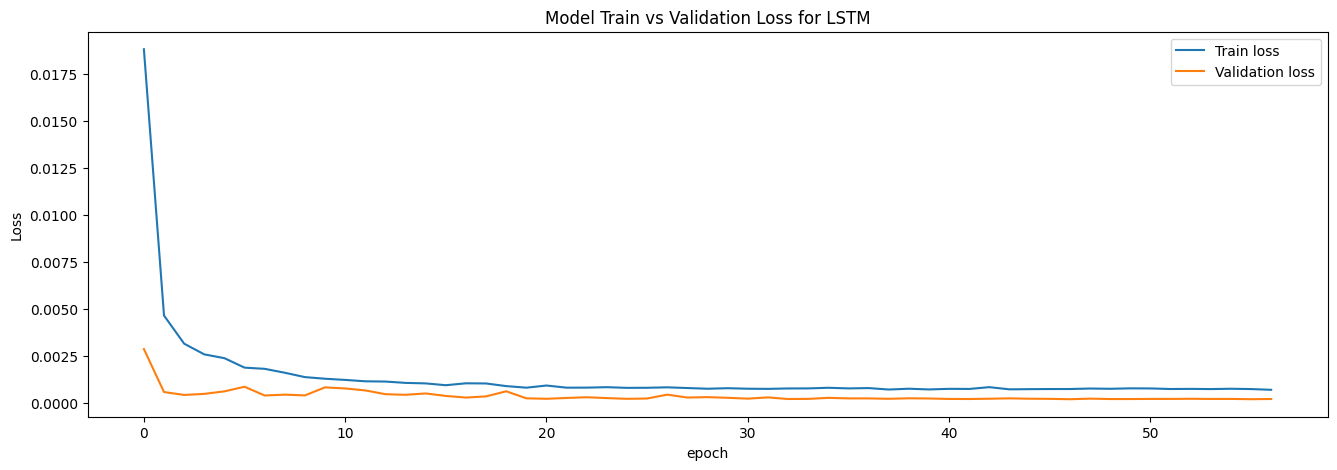

In [20]:
def plot_loss (history, model_name):
    plt.figure(figsize = (16, 5))
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model Train vs Validation Loss for ' + model_name)
    plt.ylabel('Loss')
    plt.xlabel('epoch')
    plt.legend(['Train loss', 'Validation loss'], loc='upper right')
    #plt.savefig('C:/Users/nious/Documents/Medium/LSTM&GRU/loss_'+model_name+'.jpg', format='jpg', dpi=1000)

#plot_loss (history_bilstm, 'BiLSTM')
plot_loss (history, 'LSTM')
#plot_loss (history_gru, 'GRU')

In [22]:
# Evaluate the model
mse = model.evaluate(X_test, y_test, verbose=0)
print(f'Mean Squared Error: {mse}')

Mean Squared Error: 0.0002015894715441391


In [23]:
# Make predictions on the test set
y_pred = model.predict(X_test)

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


/tmp/ipykernel_5364/2375534478.py:6: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')


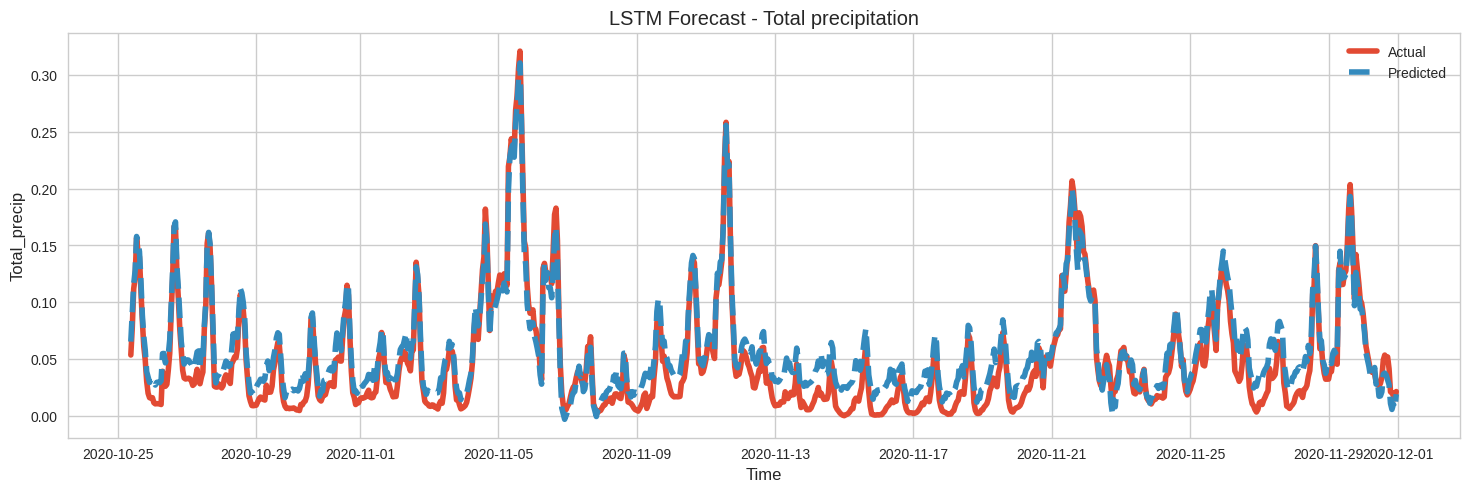

In [30]:
# Visualization
#plt.style.use('seaborn')
#plt.style.use('fivethirtyeight')
#plt.style.use('seaborn-whitegrid')
#plt.style.use('ggplot')

#########################################################
plt.figure(figsize=(16, 5))
plt.plot(test_data.index, y_test, label='Actual')
plt.plot(test_data.index, y_pred, label='Predicted', linestyle='--')
plt.xlabel('Time')
plt.ylabel(target_variable)
plt.title('LSTM Forecast - Total precipitation')
plt.legend()
plt.show()

# Hyperparameter Tuning

Optimize hyperparameters to find the best model configuration.

Grid Search: Use Grid Search to try out different combinations of hyperparameters and find the best ones.

In [65]:
from sklearn.model_selection import GridSearchCV
from scikeras.wrappers import KerasRegressor

In [20]:
def create_model(units=64,activation="tanh", dropout_rate=0.2):
    model = Sequential()
    model.add(LSTM(units, input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dropout(dropout_rate))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

In [66]:
def create_model(units=37,activation="tanh", dropout_rate=0.2): 
    model= Sequential()
    #Adding LSTM layers
    model.add(LSTM(units, 
                       return_sequences = True, 
                       input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(LSTM(units, 
                       return_sequences = False))
    model.add(Dense(25))

    #Adding the output layer
    model.add(Dense(1))
    #Compiling the model
    model.compile(optimizer = 'adam',
                      loss = 'mean_squared_error',
                      metrics = ["accuracy"])
    return model

In [67]:
model = KerasRegressor(units=32,build_fn=create_model, epochs=100, batch_size=32,dropout_rate=0.2,verbose=0)

param_grid = {
    #'units': [32, 64, 128],
    #'dropout_rate': [0.2, 0.3, 0.4],
    'batch_size': [16, 32, 64, 128],
    'epochs': [50, 100,500,1000],
    'model__activation': ['relu', 'sigmoid']
}
grid = GridSearchCV(estimator=model, param_grid=param_grid, cv=3)
grid_result = grid.fit(X_train, y_train)

print(f"Best: {grid_result.best_score_} using {grid_result.best_params_}")

/home/oem/anaconda3/lib/python3.9/site-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
/home/oem/anaconda3/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/home/oem/anaconda3/lib/python3.9/site-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
/home/oem/anaconda3/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape

/home/oem/anaconda3/lib/python3.9/site-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
/home/oem/anaconda3/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/home/oem/anaconda3/lib/python3.9/site-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
/home/oem/anaconda3/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape

/home/oem/anaconda3/lib/python3.9/site-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
/home/oem/anaconda3/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/home/oem/anaconda3/lib/python3.9/site-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
/home/oem/anaconda3/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape

/home/oem/anaconda3/lib/python3.9/site-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
/home/oem/anaconda3/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/home/oem/anaconda3/lib/python3.9/site-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
/home/oem/anaconda3/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape

/home/oem/anaconda3/lib/python3.9/site-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
/home/oem/anaconda3/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/home/oem/anaconda3/lib/python3.9/site-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
/home/oem/anaconda3/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape

/home/oem/anaconda3/lib/python3.9/site-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
/home/oem/anaconda3/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/home/oem/anaconda3/lib/python3.9/site-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
/home/oem/anaconda3/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape

/home/oem/anaconda3/lib/python3.9/site-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
/home/oem/anaconda3/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Best: 0.27022759134583757 using {'batch_size': 64, 'epochs': 500, 'model__activation': 'sigmoid'}


# Random Search
Alternatively, use Random Search for hyperparameter optimization.

In [45]:
from sklearn.model_selection import RandomizedSearchCV
param_grid = {
    'units': [32, 64, 128],
    'dropout_rate': [0.2, 0.3, 0.4],
    'batch_size': [16, 32, 64, 128],
    'epochs': [50, 100,500,1000]   
}
random = RandomizedSearchCV(estimator=model, param_distributions=param_grid, n_iter=10, cv=3)
random_result = random.fit(X_train, y_train)

print(f"Best: {random_result.best_score_} using {random_result.best_params_}")

SyntaxError: invalid syntax (747338229.py, line 11)

# Advanced Techniques
Consider some advanced techniques to further boost performance.

## Ensemble Methods: 
Combine predictions from multiple models to improve accuracy.

In [ ]:
from sklearn.ensemble import VotingRegressor

model1 = Sequential()
model1.add(LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2])))
model1.add(Dense(1))
model1.compile(optimizer='adam', loss='mean_squared_error')

model2 = Sequential()
model2.add(LSTM(128, input_shape=(X_train.shape[1], X_train.shape[2])))
model2.add(Dense(1))
model2.compile(optimizer='adam', loss='mean_squared_error')

voting = VotingRegressor([('lstm1', model1), ('lstm2', model2)])
voting.fit(X_train, y_train)
y_pred = voting.predict(X_test)

## Transfer Learning
Use a pre-trained model and fine-tune it on your dataset.

In [54]:
from keras.applications import InceptionV3

base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(X_train.shape[1], X_train.shape[2], 3))
model = Sequential()
model.add(base_model)
model.add(LSTM(64))
model.add(Dense(1))

SyntaxError: invalid syntax (3184252160.py, line 7)

## Hyperparameter Tuning Libraries
Use libraries like Optuna or Hyperopt for more sophisticated hyperparameter tuning. 

In [51]:
import optuna

def objective(trial):
    units = trial.suggest_int('units', 32, 128)
    dropout_rate = trial.suggest_uniform('dropout_rate', 0.2, 0.5)
    batch_size = trial.suggest_int('batch_size', 16, 64)
    epochs = trial.suggest_int('epochs', 50, 100)

    model = Sequential()
    model.add(LSTM(units, input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dropout(dropout_rate))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mean_squared_error')
    
    model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=0, validation_data=(X_test, y_test))
    loss = model.evaluate(X_test, y_test, verbose=0)
    return loss

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100)

print(f"Best trial: {study.best_trial.params}")

[I 2024-10-23 21:34:56,767] A new study created in memory with name: no-name-cb0263e0-0246-4650-b68f-8f1f8c6e775a
/tmp/ipykernel_1028911/3546686325.py:5: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  dropout_rate = trial.suggest_uniform('dropout_rate', 0.2, 0.5)
/home/oem/anaconda3/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
[I 2024-10-23 21:35:26,064] Trial 0 finished with value: 4.457330859963804e-08 and parameters: {'units': 107, 'dropout_rate': 0.32194499010881983, 'batch_size': 30, 'epochs': 71}. Best is trial 0 with value: 4.457330859963804e-08.
[I 2024-10-23 21:35:45,443] Trial 1 finished with value: 2.0017259316

[I 2024-10-23 21:54:57,128] Trial 33 finished with value: 1.5821045806774237e-08 and parameters: {'units': 62, 'dropout_rate': 0.4607953481928244, 'batch_size': 22, 'epochs': 73}. Best is trial 27 with value: 6.054300172309013e-09.
[I 2024-10-23 21:55:23,670] Trial 34 finished with value: 2.3475581656384747e-07 and parameters: {'units': 48, 'dropout_rate': 0.4414319515194616, 'batch_size': 27, 'epochs': 61}. Best is trial 27 with value: 6.054300172309013e-09.
[I 2024-10-23 21:55:50,062] Trial 35 finished with value: 5.974779782036421e-08 and parameters: {'units': 69, 'dropout_rate': 0.41463364885955556, 'batch_size': 31, 'epochs': 68}. Best is trial 27 with value: 6.054300172309013e-09.
[I 2024-10-23 21:56:30,057] Trial 36 finished with value: 1.7577919564359945e-08 and parameters: {'units': 38, 'dropout_rate': 0.48743502504954256, 'batch_size': 18, 'epochs': 78}. Best is trial 27 with value: 6.054300172309013e-09.
[I 2024-10-23 21:57:02,317] Trial 37 finished with value: 6.04866485787

[I 2024-10-23 22:17:24,561] Trial 69 finished with value: 1.119628976198328e-07 and parameters: {'units': 36, 'dropout_rate': 0.24969031902760586, 'batch_size': 53, 'epochs': 74}. Best is trial 27 with value: 6.054300172309013e-09.
[I 2024-10-23 22:18:04,902] Trial 70 finished with value: 3.383201629958421e-08 and parameters: {'units': 55, 'dropout_rate': 0.3984288354216812, 'batch_size': 19, 'epochs': 82}. Best is trial 27 with value: 6.054300172309013e-09.
[I 2024-10-23 22:18:49,145] Trial 71 finished with value: 1.1206350336578907e-07 and parameters: {'units': 59, 'dropout_rate': 0.4805667342502325, 'batch_size': 16, 'epochs': 79}. Best is trial 27 with value: 6.054300172309013e-09.
[I 2024-10-23 22:19:31,238] Trial 72 finished with value: 9.214477181274106e-09 and parameters: {'units': 56, 'dropout_rate': 0.47376856678262297, 'batch_size': 17, 'epochs': 76}. Best is trial 27 with value: 6.054300172309013e-09.
[I 2024-10-23 22:20:14,504] Trial 73 finished with value: 2.1934273064516

Best trial: {'units': 54, 'dropout_rate': 0.46595042436937795, 'batch_size': 16, 'epochs': 88}


In [57]:
import optuna

def objective(trial):
    units = trial.suggest_int('units', 32, 128)
    dropout_rate = trial.suggest_uniform('dropout_rate', 0.2, 0.5)
    batch_size = trial.suggest_int('batch_size', 16, 64)
    epochs = trial.suggest_int('epochs', 50, 100)
    
    regressorLSTM = Sequential()
    #Adding LSTM layers
    regressorLSTM.add(LSTM(50, 
                       return_sequences = True, 
                       input_shape=(X_train.shape[1], X_train.shape[2])))
    regressorLSTM.add(LSTM(50, 
                       return_sequences = False))
    regressorLSTM.add(Dense(25))

    #Adding the output layer
    regressorLSTM.add(Dense(1))
    #Compiling the model
    regressorLSTM.compile(optimizer = 'adam',
                      loss = 'mean_squared_error',
                      metrics = ["accuracy"])
    
    regressorLSTM.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=0, validation_data=(X_test, y_test))
    loss = model.evaluate(X_test, y_test, verbose=0)
    return loss

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100)

print(f"Best trial: {study.best_trial.params}")

[I 2024-10-25 14:45:31,481] A new study created in memory with name: no-name-2e63342f-a8a7-4911-af9d-dbac932c4128
/tmp/ipykernel_4771/3538401383.py:5: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  dropout_rate = trial.suggest_uniform('dropout_rate', 0.2, 0.5)
/home/oem/anaconda3/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
[I 2024-10-25 14:46:01,454] Trial 0 finished with value: 6.712059985147789e-06 and parameters: {'units': 37, 'dropout_rate': 0.48028874365236746, 'batch_size': 46, 'epochs': 90}. Best is trial 0 with value: 6.712059985147789e-06.
[I 2024-10-25 14:46:33,182] Trial 1 finished with value: 6.71205998514778

[I 2024-10-25 15:04:05,834] Trial 33 finished with value: 6.712059985147789e-06 and parameters: {'units': 100, 'dropout_rate': 0.43875469207380396, 'batch_size': 49, 'epochs': 97}. Best is trial 0 with value: 6.712059985147789e-06.
[I 2024-10-25 15:04:32,493] Trial 34 finished with value: 6.712059985147789e-06 and parameters: {'units': 84, 'dropout_rate': 0.36324128473678247, 'batch_size': 57, 'epochs': 94}. Best is trial 0 with value: 6.712059985147789e-06.
[I 2024-10-25 15:05:04,669] Trial 35 finished with value: 6.712059985147789e-06 and parameters: {'units': 90, 'dropout_rate': 0.4255691487893545, 'batch_size': 44, 'epochs': 98}. Best is trial 0 with value: 6.712059985147789e-06.
[I 2024-10-25 15:06:01,235] Trial 36 finished with value: 6.712059985147789e-06 and parameters: {'units': 120, 'dropout_rate': 0.39886140895332234, 'batch_size': 20, 'epochs': 92}. Best is trial 0 with value: 6.712059985147789e-06.
[I 2024-10-25 15:06:19,403] Trial 37 finished with value: 6.712059985147789

[I 2024-10-25 15:22:46,524] Trial 69 finished with value: 6.712059985147789e-06 and parameters: {'units': 109, 'dropout_rate': 0.468392727494774, 'batch_size': 18, 'epochs': 55}. Best is trial 0 with value: 6.712059985147789e-06.
[I 2024-10-25 15:23:05,648] Trial 70 finished with value: 6.712059985147789e-06 and parameters: {'units': 36, 'dropout_rate': 0.35030689477702565, 'batch_size': 53, 'epochs': 62}. Best is trial 0 with value: 6.712059985147789e-06.
[I 2024-10-25 15:23:22,430] Trial 71 finished with value: 6.712059985147789e-06 and parameters: {'units': 97, 'dropout_rate': 0.49393292966360697, 'batch_size': 63, 'epochs': 59}. Best is trial 0 with value: 6.712059985147789e-06.
[I 2024-10-25 15:23:40,935] Trial 72 finished with value: 6.712059985147789e-06 and parameters: {'units': 104, 'dropout_rate': 0.41929577521954975, 'batch_size': 60, 'epochs': 65}. Best is trial 0 with value: 6.712059985147789e-06.
[I 2024-10-25 15:23:56,325] Trial 73 finished with value: 6.712059985147789e

Best trial: {'units': 37, 'dropout_rate': 0.48028874365236746, 'batch_size': 46, 'epochs': 90}
